# Toy Example

In [1]:
import random
import io, base64

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import harmonicsonification as hs
hs.seed_everything(42)            # make results deterministic
plt.rcParams['figure.dpi'] = 100  # adjust figure resolution

## Some helper functions

The ``generate`` function contains the relevant transformation steps for preprocessing the data before sonification. This typically involves
1. getting a ``Transformation`` such as ``trans = hs.PCA()``
2. fitting it to the data using the ``trans.fit(data)`` or by directly providing the data upon construction as in ``trans = hs.PCA(data)``
3. transforming the data using ``data_transformed = trans.transform(data, norm)``

The transformation can be applied to any data set, including ones than is was not fitted to. The ``norm`` parameter should be either ``'g'`` for global normalisation (typically for amplitude modulation to preserve relative magnitudes between dimensions) or ``'i'`` for individual normalisation (typically for frequency modulation to rescale all dimensions to unit range).

In [2]:
def gaussian(dim, size, scale=3):
    """Generate multidimensional Gaussian data"""
    mean = np.random.uniform(-1, 1, dim)
    cov = np.random.uniform(-3, 3, (dim, dim))
    cov = cov.T @ cov
    cov += 0.1 * np.eye(dim)
    cov *= 2
    data = np.random.multivariate_normal(mean=mean, cov=cov, size=size)
    return data

def uniform(dim, size, scale=15):
    """Generate multidimensional uniform data"""
    return np.random.uniform(-scale, scale, (size, dim))

def generate(dim, n_data, n_out):
    """Generate data and perform PCA"""
    # data (Gaussian) and outlier (uniform)
    data = gaussian(dim=dim, size=n_data)
    outlier = uniform(dim=dim, size=n_out)
    # get transformation from PCA
    trans = hs.PCA(data)
    # get transformed data
    data_global = trans.transform(data, norm='g')  # global normalisation (better for AM)
    data_individual = trans.transform(data, norm='i')   # individual normalisation (better for FM)
    outlier_global = trans.transform(outlier, norm='g')
    outlier_individual = trans.transform(outlier, norm='i')
    return trans, data, data_global, data_individual, outlier, outlier_global, outlier_individual

def plot_2D(ax, outlier=None, data=None, m=None, e=None):
    """Plot 2-dimensionsl data and outlier with basis vectors from PCA"""
    data_kwargs = dict(s=1, c='blue')
    outlier_kwargs = dict(s=1, c='orange')
    arrow_kwargs = dict(color='r', width=0.02, head_width=0.1, length_includes_head=True)
    if outlier is not None:
        ax.scatter(*outlier.T, **outlier_kwargs)
    if data is not None:
        ax.scatter(*data.T, **data_kwargs)
    if m is not None and e is not None:
        for i in range(2):
            ax.arrow(m[0], m[1], e[i][0], e[i][1], **arrow_kwargs)

def plot_ND(ax, outlier=None, data=None, data_kwargs=(), outlier_kwargs=()):
    """Plot n-dimensional data and outlier"""
    data_kwargs = {**dict(color='blue', alpha=0.01), **dict(data_kwargs)}
    outlier_kwargs = {**dict(color='orange', alpha=0.01), **dict(outlier_kwargs)}
    arrow_kwargs = dict(color='r', width=0.02, head_width=0.1, length_includes_head=True)
    if outlier is not None:
        ax.plot(outlier.T, **outlier_kwargs)
    if data is not None:
        ax.plot(data.T, **data_kwargs)

def fig_to_html(fig):
    """Get HTML from figure for display in table"""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight")
    plt.close(fig)  # don't show in notebook
    buf.seek(0)     # rewind buffer
    png_base64 = base64.b64encode(buf.getbuffer()).decode("ascii")
    html_img_tag = f'<img src="data:image/png;base64,{png_base64}"/>'
    return html_img_tag

def spec(audio, **kwargs):
    """Plot spectrogram with harmonic reference lines"""
    f0 = kwargs['f0']
    in_octave = kwargs.get('in_octave', False)
    prime = kwargs.get('prime', False)
    
    x = audio.freqs
    y = audio.amps
    ticks = hs.harmonics(f0=f0, n=len(x), prime=prime)
    if in_octave:
        ticks = hs.freqs_to_octave(ticks, f0=kwargs['f0'])
    
    fig, ax = plt.subplots(1, 1, figsize=(5, 1))
    ax.vlines(ticks, np.zeros_like(x), y, ls='--', color='black')
    ax.vlines(x, np.zeros_like(x), y, color='blue')
    if in_octave:
        ticks = np.array(list(ticks) + [2 * f0])
    ax.set_xticks(ticks[::len(ticks)//5+1])
    if in_octave:
        ax.set_xlim(0.9 * f0, 2.1 * f0)
    else:
        ax.set_xlim(0, None)
    return fig

def get_table(method, heading, data, outlier, n=5, **kwargs):
    """Get a nice table with audio and spectrograms"""
    table = r"<tr><th>" + f"</th><th>".join(["Index", "Data", "Spectrum", "Outlier", "Spectrum"]) + r"</th></tr>"
    for i in range(n):
        table += r"<tr>"
        table += fr"<td>{i}</td>"
        for s in [
            # Here is where the actual sonification happens using sonify_kwargs from below
            hs.sonify(method, data[i], **kwargs),
            hs.sonify(method, outlier[i], **kwargs),
        ]:
            table += fr"<td>{s.html}</td>"
            table += fr"<td>{fig_to_html(spec(s, **kwargs))}</td>"
        table += r"</tr>"
    display(HTML(f"<h3>{heading}</h3><table>{table}</table>"))

## 2D data

In [3]:
trans, data, data_global, data_individual, outlier, outlier_global, outlier_individual = generate(dim=2, n_data=1000, n_out=500)

### Overview of transformations

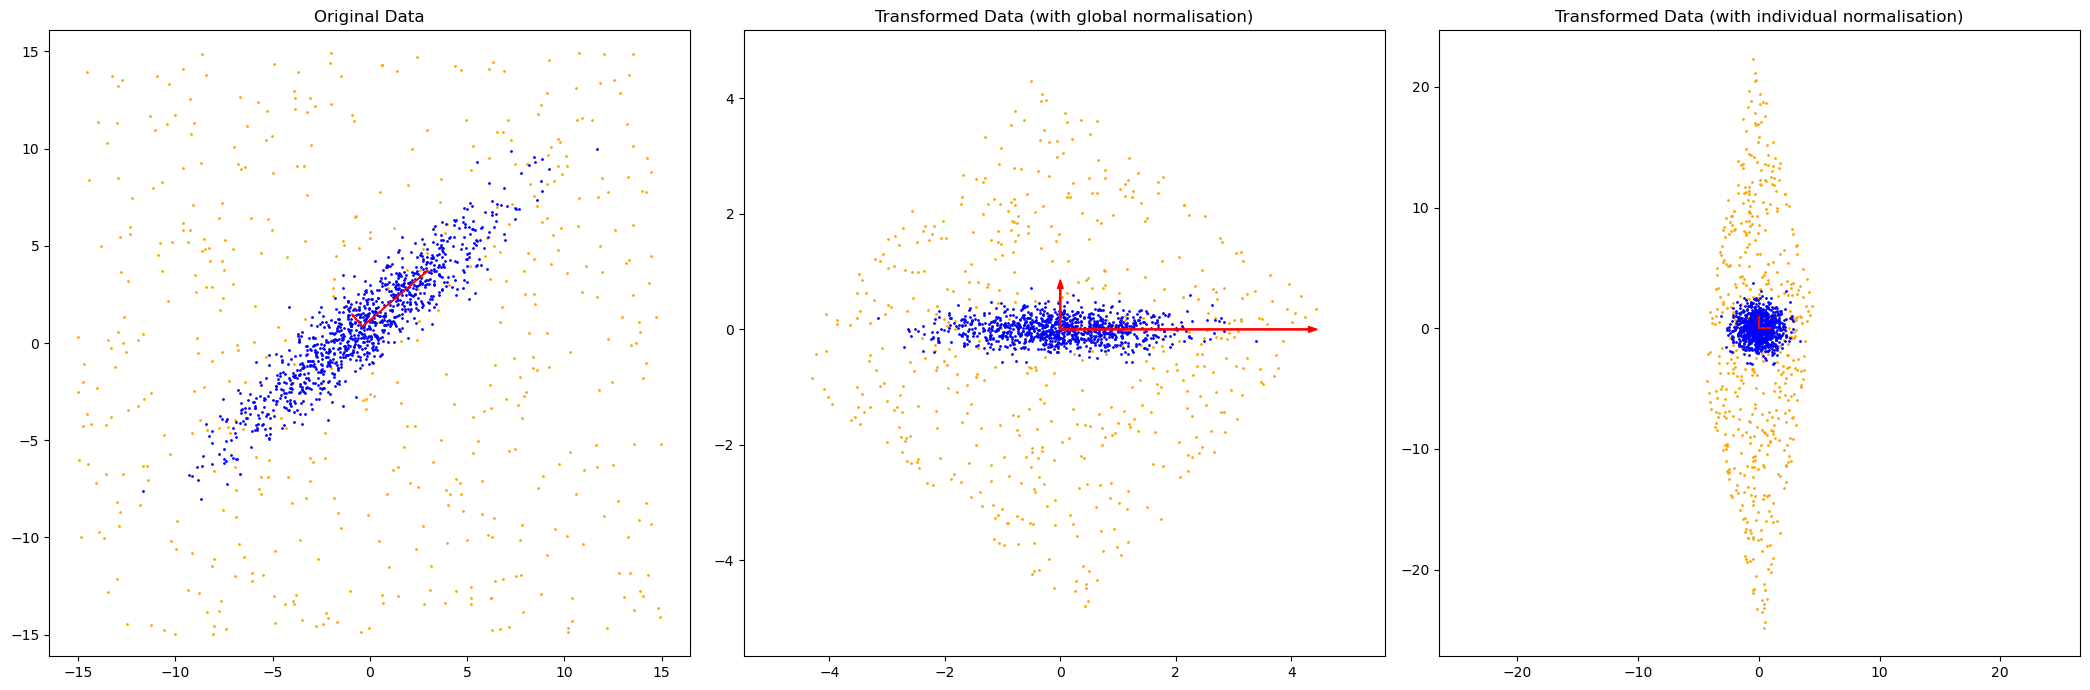

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
plot_2D(ax=axes[0], outlier=outlier, data=data, m=trans.mean, e=trans.eig * trans.std[:, None])
plot_2D(ax=axes[1], outlier=outlier_global, data=data_global, m=[0, 0], e=[[trans.std[0], 0], [0, trans.std[1]]])
plot_2D(ax=axes[2], outlier=outlier_individual, data=data_individual, m=[0, 0], e=[[1, 0], [0, 1]])

for ax, t in zip(axes, ["Original Data", "Transformed Data (with global normalisation)", "Transformed Data (with individual normalisation)"]):
#   ax.axis('off')  # don't show axes
    ax.axis('equal')
    ax.set_title(t)
fig.tight_layout()

### Parameters for sonification

In [5]:
sonify_kwargs = dict(
    f0=220,                      # 220Hz is better for small speakers/headphones
    add_f0=True,                 # add f0 for orientation (only modulate higher partials above)
#   prime=True, in_octave=True,  # use prime harmonics and map everything to one octave
)

This is how you can sonify the individual data points. The table with examples below does exactly this.

In [6]:
hs.sonify('am', data_global[0], **sonify_kwargs).display()
hs.sonify('am', outlier_global[0], **sonify_kwargs).display()
hs.sonify('fm', data_individual[0], **sonify_kwargs).display()
hs.sonify('fm', outlier_individual[0], **sonify_kwargs).display()

### Table with examples

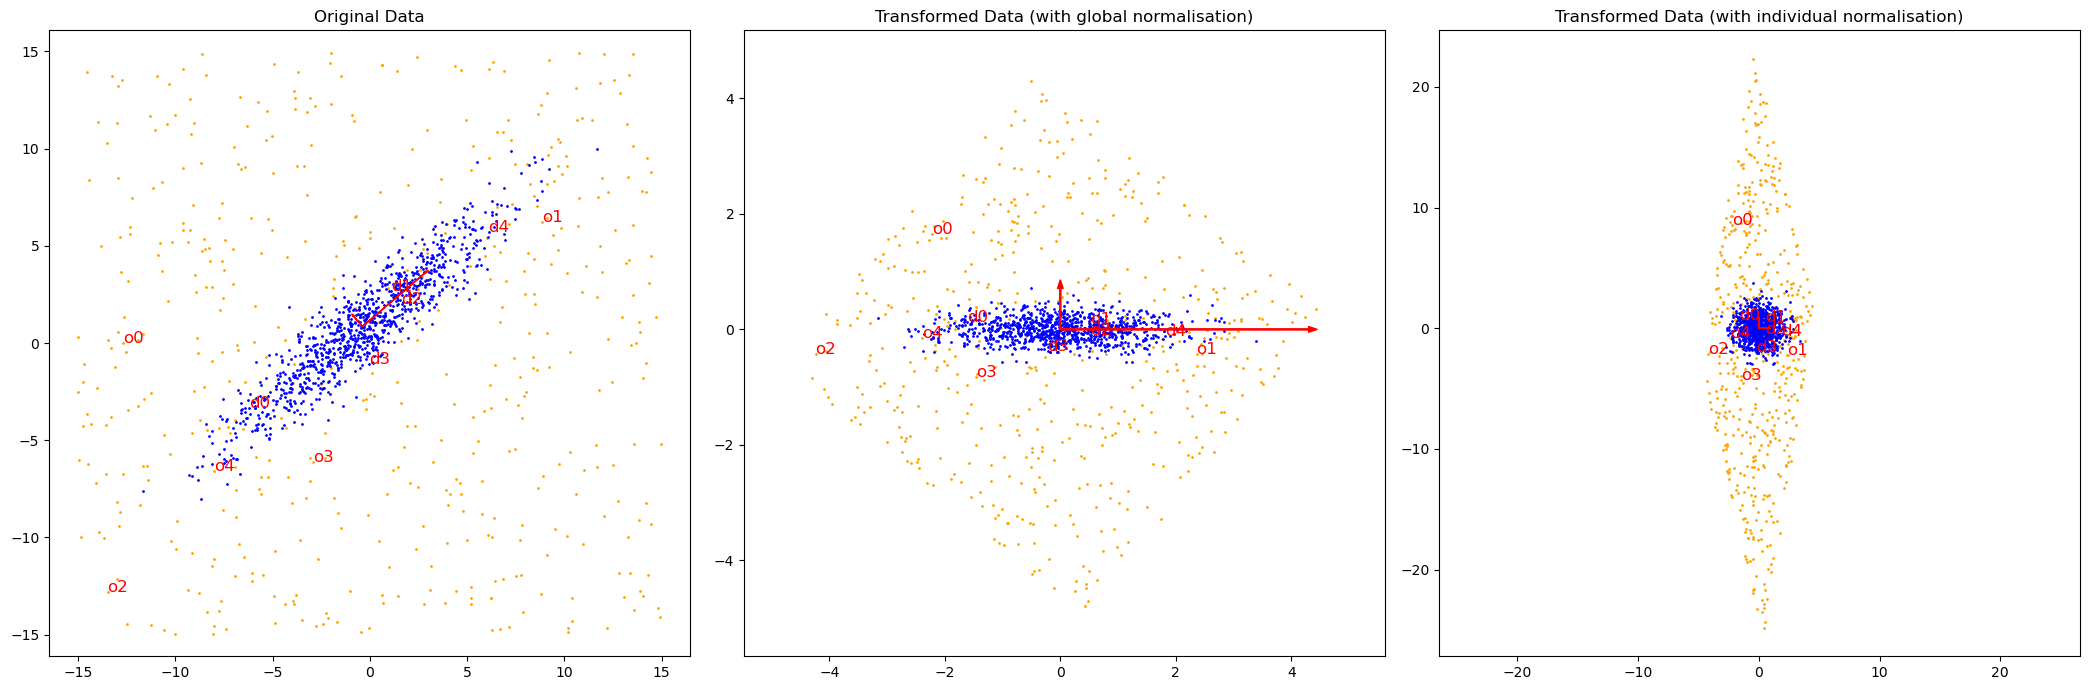

Index,Data,Spectrum,Outlier,Spectrum
0,Your browser does not support the audio element.,,Your browser does not support the audio element.,
1,Your browser does not support the audio element.,,Your browser does not support the audio element.,
2,Your browser does not support the audio element.,,Your browser does not support the audio element.,
3,Your browser does not support the audio element.,,Your browser does not support the audio element.,
4,Your browser does not support the audio element.,,Your browser does not support the audio element.,

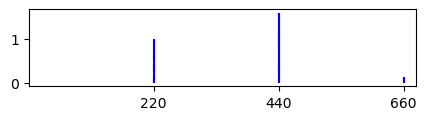
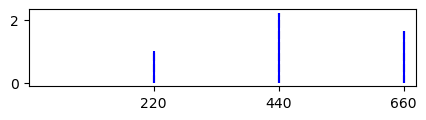
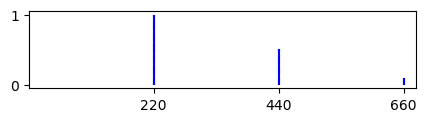
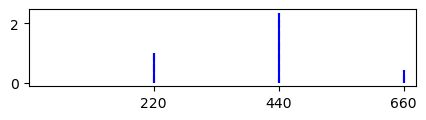
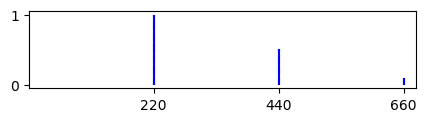
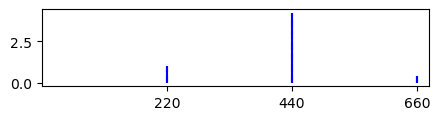
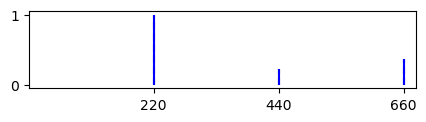
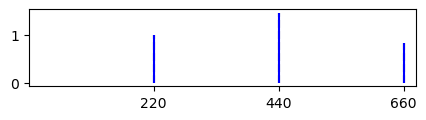
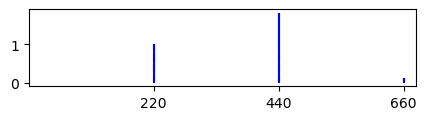
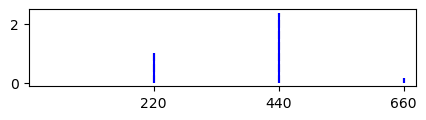

Index,Data,Spectrum,Outlier,Spectrum
0,Your browser does not support the audio element.,,Your browser does not support the audio element.,
1,Your browser does not support the audio element.,,Your browser does not support the audio element.,
2,Your browser does not support the audio element.,,Your browser does not support the audio element.,
3,Your browser does not support the audio element.,,Your browser does not support the audio element.,
4,Your browser does not support the audio element.,,Your browser does not support the audio element.,

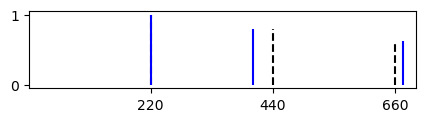
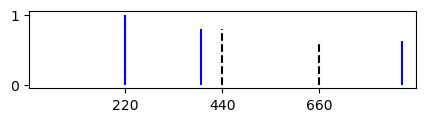
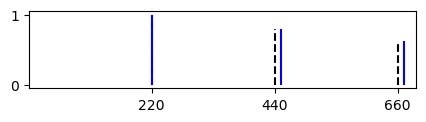
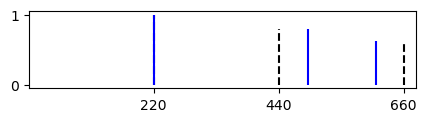
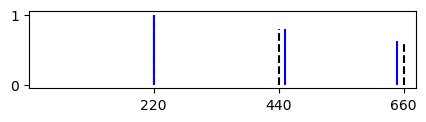
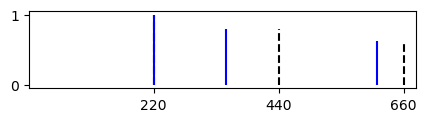
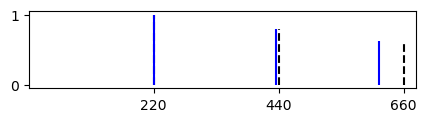
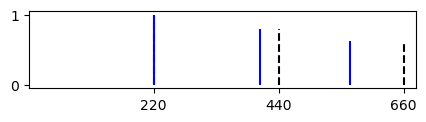
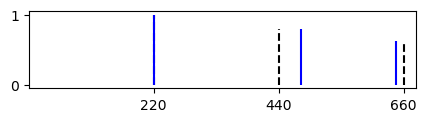
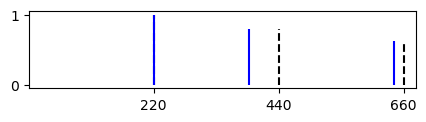

In [7]:
# ... add labels for some data/outlier points to the figure above
for ax, points, l in [
    (axes[0], data, 'd'), (axes[0], outlier, 'o'), 
    (axes[1], data_global, 'd'), (axes[1], outlier_global, 'o'),
    (axes[2], data_individual, 'd'), (axes[2], outlier_individual, 'o'),
]:
    for i in range(5):
        ax.text(x=points[i][0], y=points[i][1], s=f"{l}{i}", color='red', fontsize=12)
display(fig)

get_table(method='am', heading="Amplitude Modulation", data=data_global, outlier=outlier_global, **sonify_kwargs)
get_table(method='fm', heading="Frequency Modulation", data=data_individual, outlier=outlier_individual, **sonify_kwargs)

## ND data

In [8]:
trans, data, data_global, data_individual, outlier, outlier_global, outlier_individual = generate(dim=16, n_data=500, n_out=500)

### Table with examples

Index,Data,Spectrum,Outlier,Spectrum
0,Your browser does not support the audio element.,,Your browser does not support the audio element.,
1,Your browser does not support the audio element.,,Your browser does not support the audio element.,
2,Your browser does not support the audio element.,,Your browser does not support the audio element.,
3,Your browser does not support the audio element.,,Your browser does not support the audio element.,
4,Your browser does not support the audio element.,,Your browser does not support the audio element.,

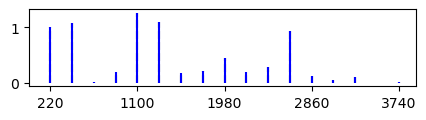
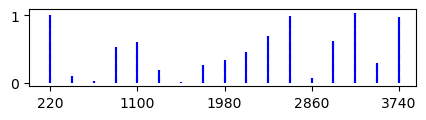
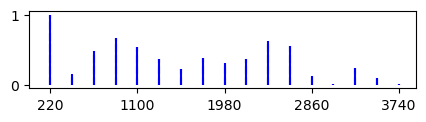
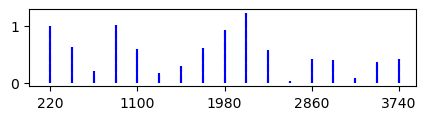
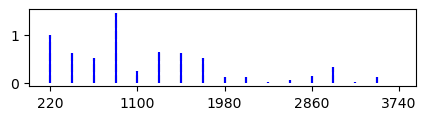
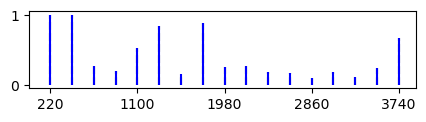
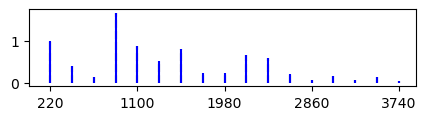
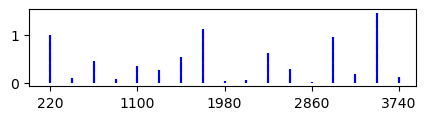
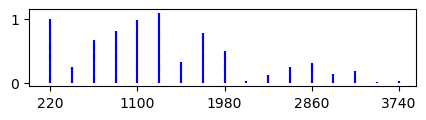
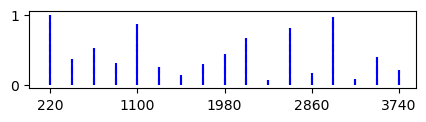

Index,Data,Spectrum,Outlier,Spectrum
0,Your browser does not support the audio element.,,Your browser does not support the audio element.,
1,Your browser does not support the audio element.,,Your browser does not support the audio element.,
2,Your browser does not support the audio element.,,Your browser does not support the audio element.,
3,Your browser does not support the audio element.,,Your browser does not support the audio element.,
4,Your browser does not support the audio element.,,Your browser does not support the audio element.,

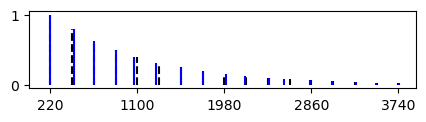
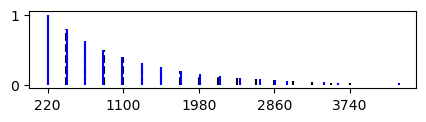
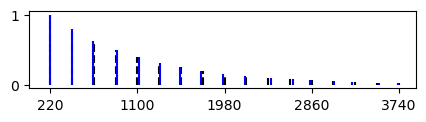
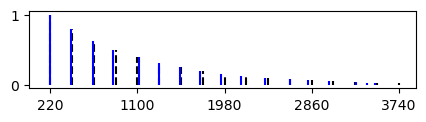
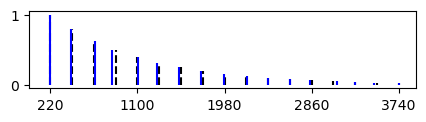
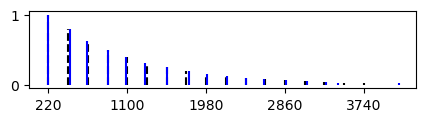
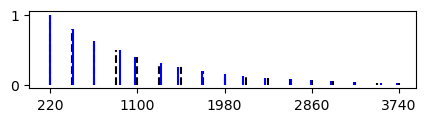
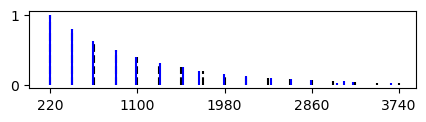
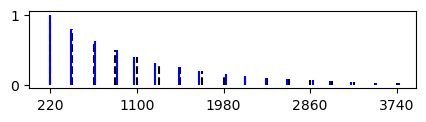
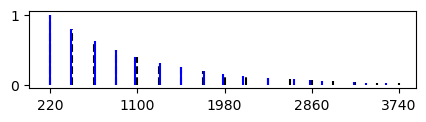

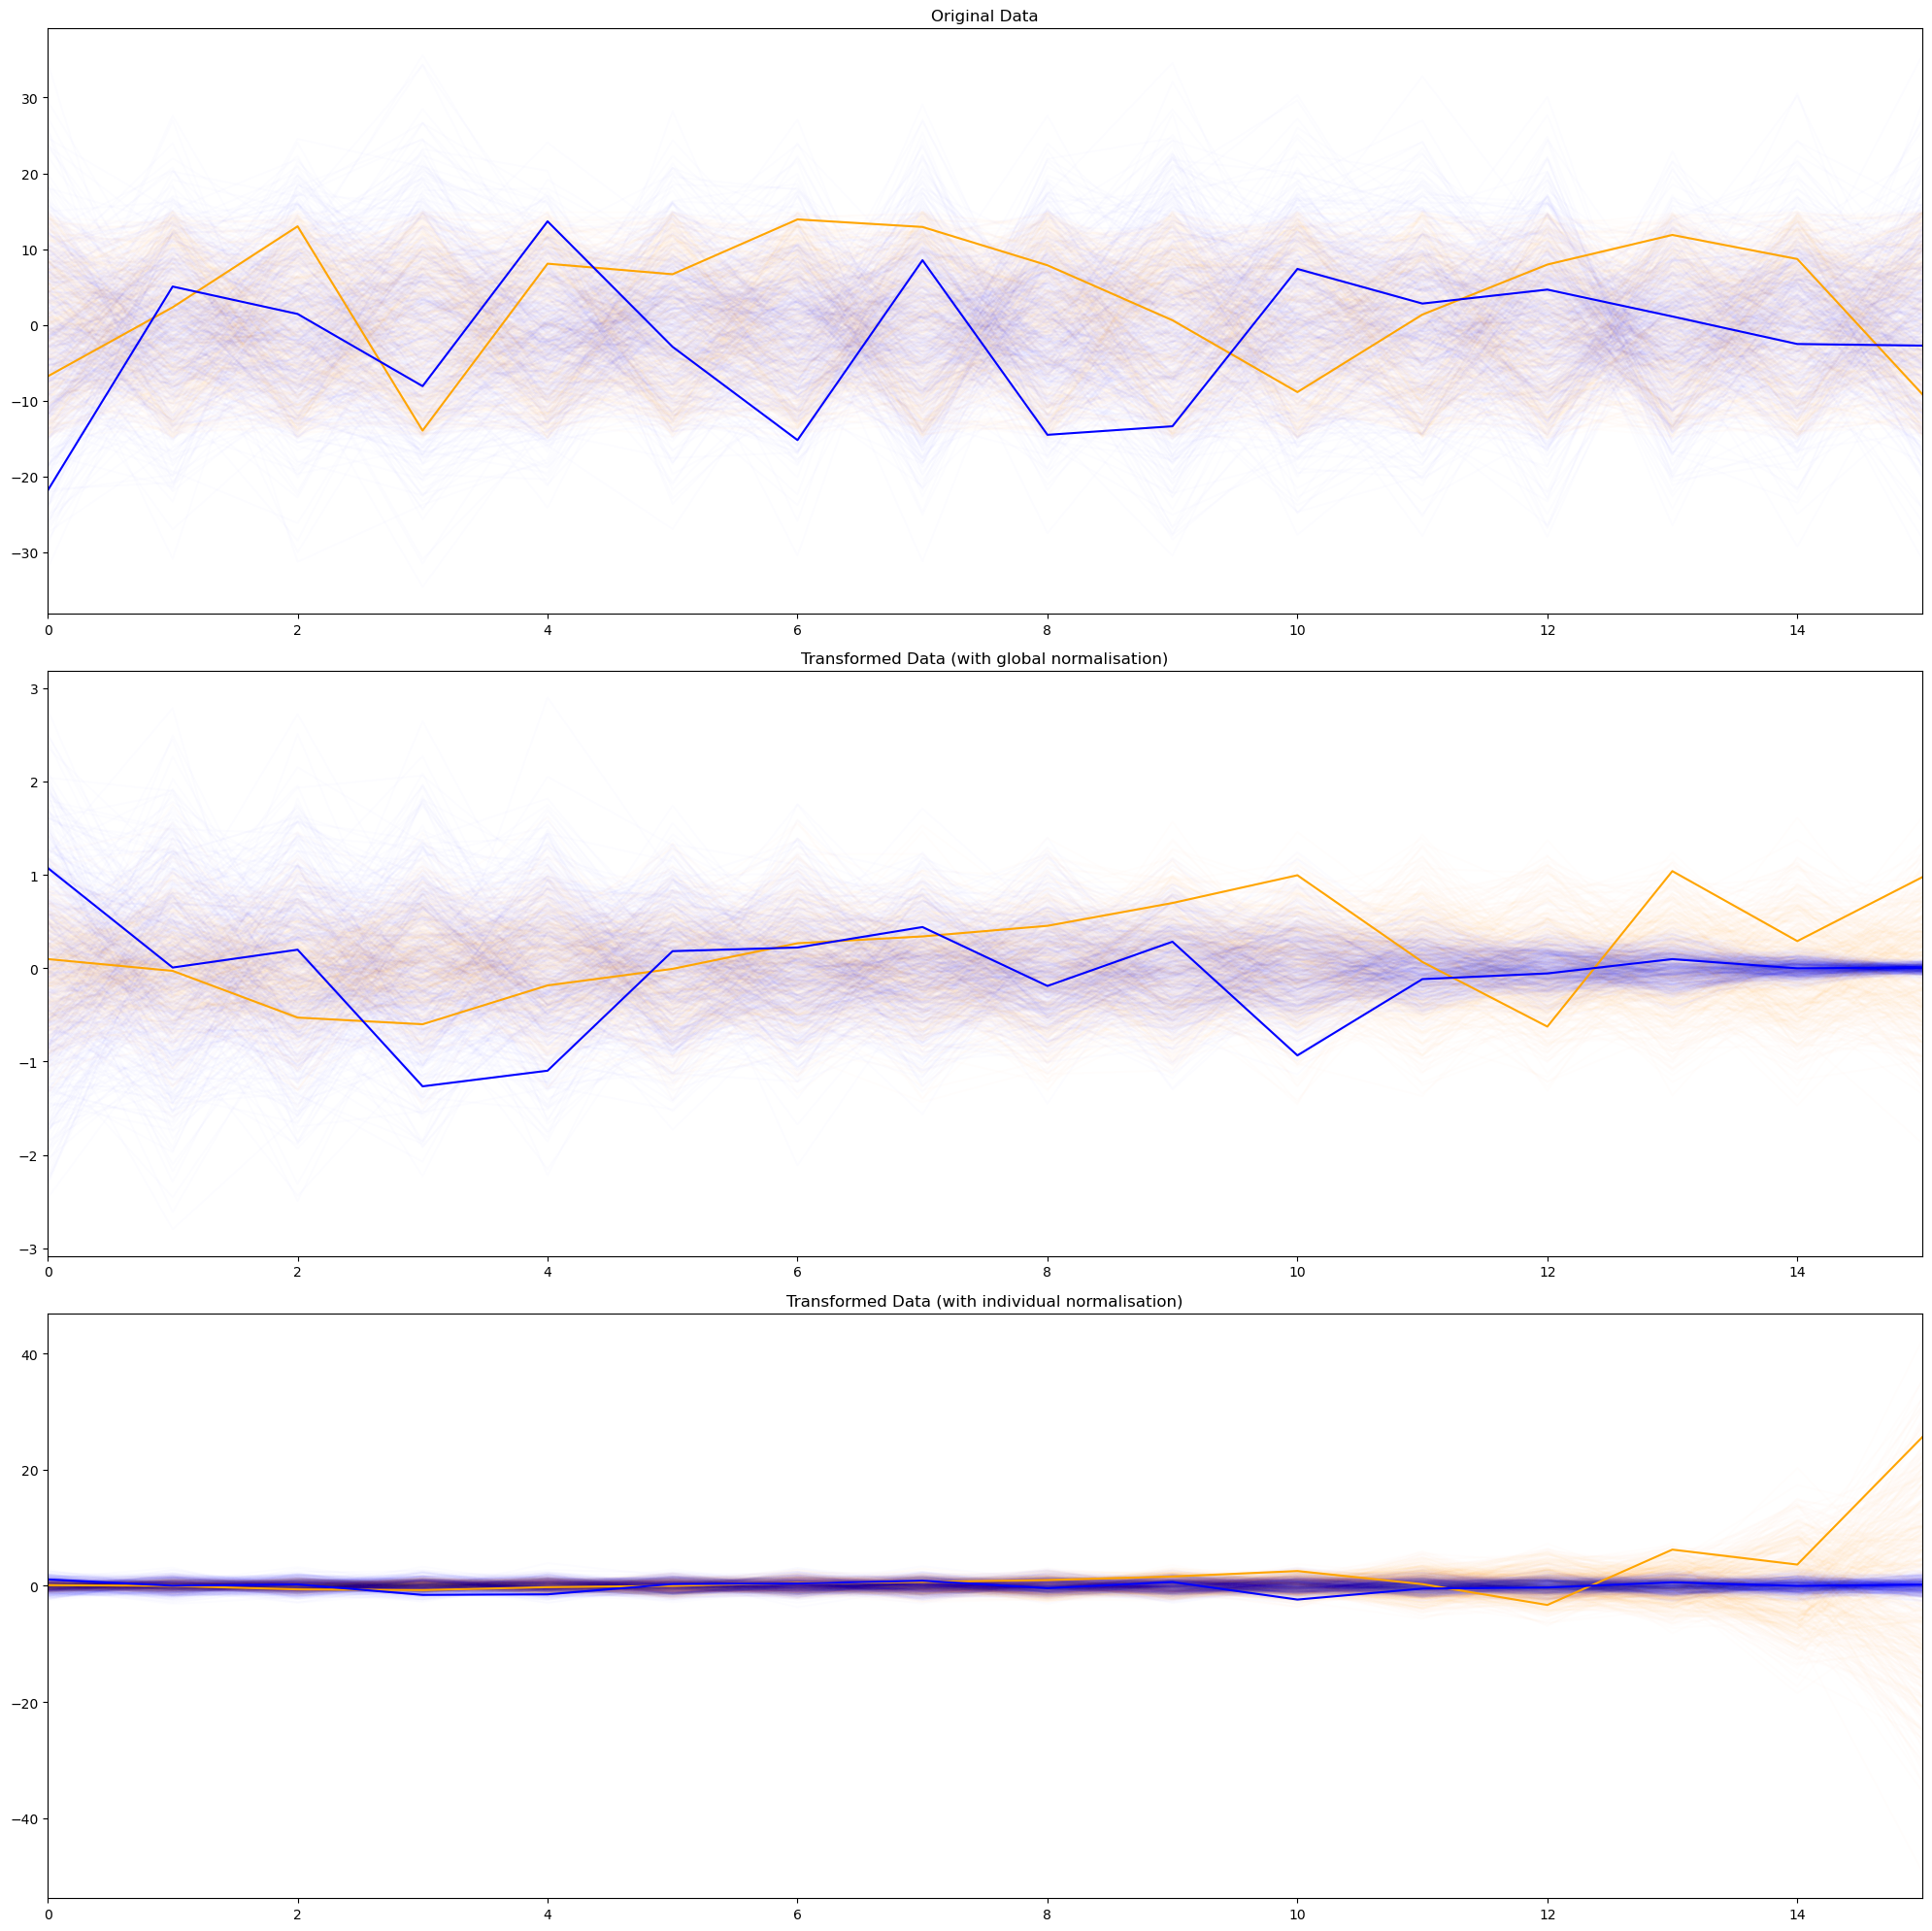

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(20, 20))

plot_ND(ax=axes[0], outlier=outlier, data=data)
plot_ND(ax=axes[1], outlier=outlier_global, data=data_global)
plot_ND(ax=axes[2], outlier=outlier_individual, data=data_individual)

# highlight one individual data/outlier point (here as a line because it is high-dimensional)
kwargs = dict(data_kwargs=dict(alpha=1), outlier_kwargs=dict(alpha=1))
plot_ND(ax=axes[0], outlier=outlier[0], data=data[0], **kwargs)
plot_ND(ax=axes[1], outlier=outlier_global[0], data=data_global[0], **kwargs)
plot_ND(ax=axes[2], outlier=outlier_individual[0], data=data_individual[0], **kwargs)


for ax, t in zip(axes, ["Original Data", "Transformed Data (with global normalisation)", "Transformed Data (with individual normalisation)"]):
#   ax.axis('off')  # don't show axes
    ax.set_xlim(0, data.shape[1] - 1)
    ax.set_title(t)
fig.tight_layout()

get_table(method='am', heading="Amplitude Modulation", data=data_global, outlier=outlier_global, **sonify_kwargs)
get_table(method='fm', heading="Frequency Modulation", data=data_individual, outlier=outlier_individual, **sonify_kwargs)